# Homework 7 - Statistics & ML
## BIOMEDE 241, Winter 2026

Please download a copy of this file via Canvas and open with Google Colaboratory, which can be found at colab.research.google.com. After finishing all of the exercises by entering all of your code, please save a completed version of this file and upload to Canvas under the assignment for this week. Please pay careful attention to how the answer should be displayed in the code (for example as a number or a plot), as the graders will run your code and primarily check the output.

If you have used AI assistance on anything you submit for BME 241
HW please disclose that you did so, and include an explanation at the top of your HW or
individual HW problem of how you used it. For example: “I used a chatbot to generate a short
tutorial with example code on how to use the ‘arange’ command” or “I used the chatbot to help
me find a bug in my code in which it was only executing the for loop once.”

Include any libraries you need here:

In [18]:
import statistics as stats
import numpy as np
import matplotlib.pyplot as plt
import math
import scipy.stats
import pandas as pd
import statsmodels.api as sm
from statsmodels.formula.api import ols
from scipy.stats import f, chi2
from scipy.optimize import minimize
from sklearn.datasets import load_iris, make_classification
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score

np.random.seed(42)

%matplotlib inline

# 1. Linear Regression

We are going to predict the grip force produced by the hand based on simulated
recordings of EMG (electromyography) signal amplitudes from forearm
muscles. The grip force of the hand will be varying between 0 N and 100 N.

a. First, let's make some simulated data.
   Make an 'x' variable representing EMG amplitude that ranges from 0 to 100
   in 0.5-unit increments. Use reshape() to make it a column vector.
   Then generate a set of grip forces 'y' for a simulated muscle whose force output
   is equal to 1.8*x + 4 Newtons. Calculate y for all x. Plot x vs y,
   which should give you a straight line.

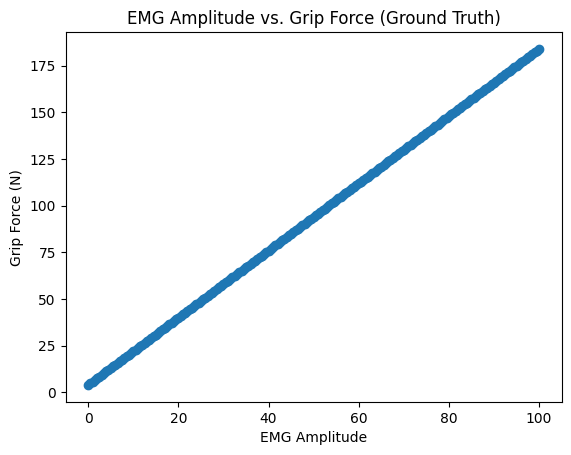

In [19]:
x = np.arange(0, 100.5, 0.5).reshape(-1, 1)
y = 1.8 * x + 4

plt.scatter(x, y)
plt.xlabel('EMG Amplitude')
plt.ylabel('Grip Force (N)')
plt.title('EMG Amplitude vs. Grip Force (Ground Truth)')
plt.show()

>b. Now add noise to the signal. Assume the noise is a Poisson random variable
   with lambda = 8 Newtons. Generate a list of random Poisson values the same
   length as y and add it to y to make 'ynoisy'. Plot x vs ynoisy.
   The linear relationship should be visible but noisy.

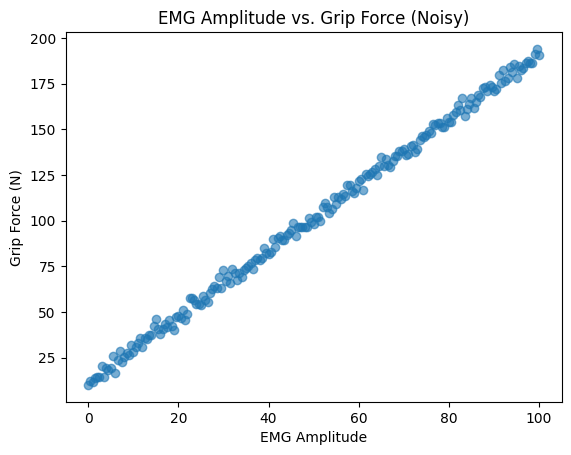

In [20]:
noise = np.random.poisson(lam=8, size=y.shape)
ynoisy = y + noise

plt.scatter(x, ynoisy, alpha=0.6)
plt.xlabel('EMG Amplitude')
plt.ylabel('Grip Force (N)')
plt.title('EMG Amplitude vs. Grip Force (Noisy)')
plt.show()

>c.	Assuming we didn’t know that initial relationship, we’re going to measure it by doing a regression and see if we recover the same numbers we put in. First, calculate the sum of squares for x, the sum of squares for y, and the sum of squares for xy, and state these values. Make sure you are using ynoisy instead of y.

In [21]:
n = len(x)
x_flat = x.flatten()
y_flat = ynoisy.flatten()

SS_xx = np.sum(x_flat**2) - n * np.mean(x_flat)**2
SS_yy = np.sum(y_flat**2) - n * np.mean(y_flat)**2
SS_xy = np.sum(x_flat * y_flat) - n * np.mean(x_flat) * np.mean(y_flat)

print(f"SS_xx (sum of squares for x):  {SS_xx:.4f}")
print(f"SS_yy (sum of squares for y):  {SS_yy:.4f}")
print(f"SS_xy (sum of squares for xy): {SS_xy:.4f}")

SS_xx (sum of squares for x):  169175.0000
SS_yy (sum of squares for y):  552270.4368
SS_xy (sum of squares for xy): 305293.0000


>d.	Next, use the equations we saw in class to calculate the likely slope ‘b1’ and the intercept ‘b0’. Do those values match what you put in?

In [22]:
b1 = SS_xy / SS_xx
b0 = np.mean(y_flat) - b1 * np.mean(x_flat)

print(f"Slope     b1 = {b1:.4f}  (true: 1.8)")
print(f"Intercept b0 = {b0:.4f}  (true: ~12 = 4 + Poisson mean of 8)")

Slope     b1 = 1.8046  (true: 1.8)
Intercept b0 = 11.6407  (true: ~12 = 4 + Poisson mean of 8)


>e.	Using your coefficients, b0 and b1, plot a fit line on top of your noisy data.

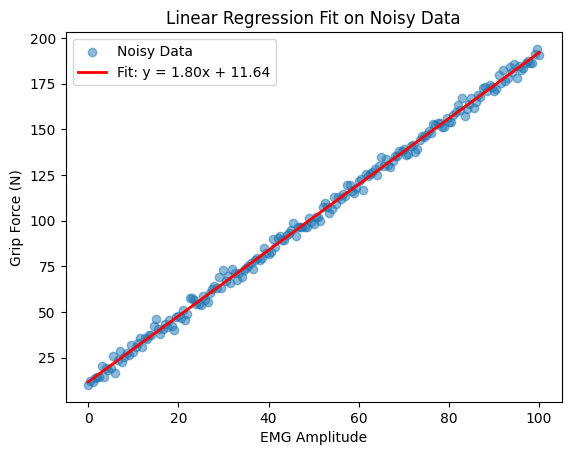

In [23]:
y_fit = b1 * x_flat + b0

plt.scatter(x, ynoisy, alpha=0.5, label='Noisy Data')
plt.plot(x_flat, y_fit, color='red', linewidth=2, label=f'Fit: y = {b1:.2f}x + {b0:.2f}')
plt.xlabel('EMG Amplitude')
plt.ylabel('Grip Force (N)')
plt.title('Linear Regression Fit on Noisy Data')
plt.legend()
plt.show()

>f.	Now let’s do this with linear algebra. First, add a second dimension to your x variable that is all ones.

In [24]:
X_design = np.hstack([x, np.ones((len(x), 1))])
print("Shape of X_design:", X_design.shape)
print("First 3 rows:\n", X_design[:3])

Shape of X_design: (201, 2)
First 3 rows:
 [[0.  1. ]
 [0.5 1. ]
 [1.  1. ]]


> g.	Using the linear regression matrix solution we saw in class, which involves x and ynoisy, solve for a ‘B’ vector with two elements. They should be equal to the values in e. This line of code can now be used for multiple linear regression for any number of features (so long as it includes a row or column of ones for the offset term). You'll need look up how to do these matrix operations in Python.

In [25]:
# B = (X^T X)^-1 X^T y  — the normal equations
B = np.linalg.lstsq(X_design, ynoisy, rcond=None)[0]
print(f"B = {B.flatten()}")
print(f"B[0] (slope)     = {B[0][0]:.4f}  (matches b1 = {b1:.4f})")
print(f"B[1] (intercept) = {B[1][0]:.4f}  (matches b0 = {b0:.4f})")

B = [ 1.80459879 11.64070735]
B[0] (slope)     = 1.8046  (matches b1 = 1.8046)
B[1] (intercept) = 11.6407  (matches b0 = 11.6407)


>h.	Next, **reverse the regression so that you are predicting x from y instead of vice versa**. Note that you need to add a column of ones to y. Report your new B values.

In [26]:
# Reverse: predict x (EMG) from ynoisy (force)
Y_design = np.hstack([ynoisy, np.ones((len(ynoisy), 1))])
B_reverse = np.linalg.lstsq(Y_design, x, rcond=None)[0]
print(f"B_reverse = {B_reverse.flatten()}")
print(f"Slope: {B_reverse[0][0]:.4f},  Intercept: {B_reverse[1][0]:.4f}")

B_reverse = [ 0.5527962  -6.31370664]
Slope: 0.5528,  Intercept: -6.3137


> i.	With your new B matrix, generate an ‘xpred’ variable which is your best prediction of x based on the data in y. Plot it with plt.plot(xpred) to make sure it makes sense. It should look like a noisy version of your original x vector which spanned from 0 to 200.

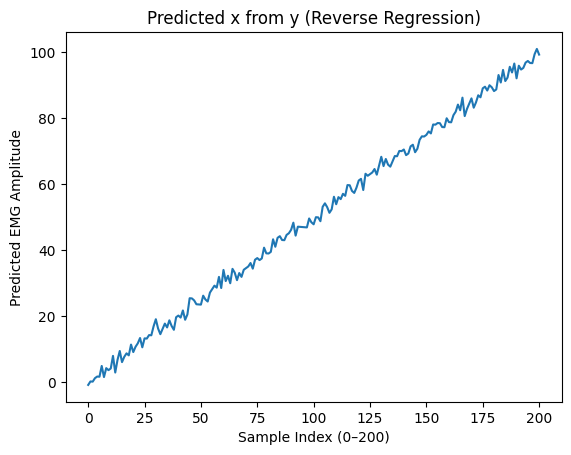

In [27]:
xpred = Y_design @ B_reverse

plt.plot(xpred)
plt.xlabel('Sample Index (0–200)')
plt.ylabel('Predicted EMG Amplitude')
plt.title('Predicted x from y (Reverse Regression)')
plt.show()

## **Parts j–l use simulated multi-neuron EMG data generated below.**

> j.	The data below simulates 80 seconds of recordings from a 64-channel EMG
   electrode array placed over the forearm during grip force tasks.
   'y_emg' contains the rectified EMG amplitudes (64 channels + time-lagged
   copies; the ones column has already been added).
   'x_force' contains the measured grip force.
   Use your regression equation to compute 'B_emg' and report the size of your matrix.

In [28]:
## Generated code here, do not change.
n_samples = 800
n_channels = 64
true_weights = np.random.randn(n_channels) * 0.5
t_emg = np.linspace(0, 80, n_samples)
x_force_true = 3 * np.sin(2 * np.pi * t_emg / 20) + 5  # Sinusoidal force profile (N)
emg_base = np.outer(x_force_true, true_weights) + np.random.randn(n_samples, n_channels) * 2
ones_col = np.ones((n_samples, 1))
y_emg = np.hstack([ones_col, emg_base])           # shape: (800, 65)  — ones + 64 channels
x_force = x_force_true.reshape(n_samples, 1)       # shape: (800, 1)


## YOUR CODE HERE
B_emg = np.linalg.lstsq(y_emg, x_force, rcond=None)[0]
print(f"Size of B_emg: {B_emg.shape}")  # should be (65, 1)

Size of B_emg: (65, 1)


>k.	Generate a predicted 'xpred_force' variable by multiplying y_emg by B_emg.
   Plot both the real grip force in 'x_force' and 'xpred_force' on the same
   graph as a function of time. Traces should appear highly correlated.

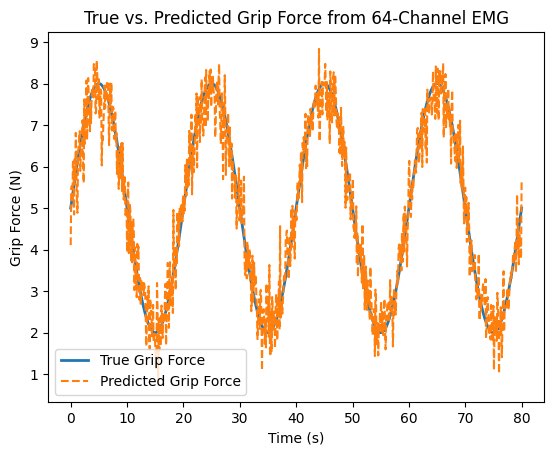

In [29]:
xpred_force = y_emg @ B_emg

plt.plot(t_emg, x_force, label='True Grip Force', linewidth=2)
plt.plot(t_emg, xpred_force, label='Predicted Grip Force', linestyle='--', linewidth=1.5)
plt.xlabel('Time (s)')
plt.ylabel('Grip Force (N)')
plt.title('True vs. Predicted Grip Force from 64-Channel EMG')
plt.legend()
plt.show()

>l.	Calculate the Peason’s correlation value x_force and xpred_force using any of the sum of squares equations we saw in class. Check that your result matches that from Python function ‘pearsonr()' in scipy.stats.

In [30]:
x_f  = x_force.flatten()
xp_f = xpred_force.flatten()

SS_xx_f = np.sum((x_f  - np.mean(x_f))**2)
SS_yy_f = np.sum((xp_f - np.mean(xp_f))**2)
SS_xy_f = np.sum((x_f  - np.mean(x_f)) * (xp_f - np.mean(xp_f)))

r_manual = SS_xy_f / np.sqrt(SS_xx_f * SS_yy_f)
r_scipy, p_scipy = scipy.stats.pearsonr(x_f, xp_f)

print(f"Pearson r (manual SS formula): {r_manual:.6f}")
print(f"Pearson r (scipy.stats):       {r_scipy:.6f}  (p = {p_scipy:.2e})")
print("Values match:", np.isclose(r_manual, r_scipy))

Pearson r (manual SS formula): 0.970667
Pearson r (scipy.stats):       0.970667  (p = 0.00e+00)
Values match: True


# 2. ANOVA, Analysis of Variance.

a. We are studying the effect of three rehabilitation protocols (Protocol X,
   Protocol Y, Protocol Z) on the range of motion (ROM) recovery (in degrees)
   after shoulder surgery. Create two simulated datasets of n_i = 12 observations
   each for the three protocols using the numpy.random.normal distribution.

   In both datasets, the means should be 75, 80, and 89 degrees for X, Y, Z.
   In 'dataset1', use a standard deviation of 2 (tight distributions).
   In 'dataset2', use a standard deviation of 8 (wide distributions).

   Make treatments columns and observations rows.

In [31]:
np.random.seed(42)
n_i = 12
means = [75, 80, 89]

dataset1 = np.column_stack([np.random.normal(m, 2, n_i) for m in means])
dataset2 = np.column_stack([np.random.normal(m, 8, n_i) for m in means])

print("Dataset1 shape:", dataset1.shape)
print("Dataset2 shape:", dataset2.shape)

Dataset1 shape: (12, 3)
Dataset2 shape: (12, 3)


> b. Plot the means in both datasets with error bars for their standard deviation.
   This should show 6 data points (X, Y, Z for dataset1 and dataset2) with
   larger error bars for the dataset with higher standard deviation.



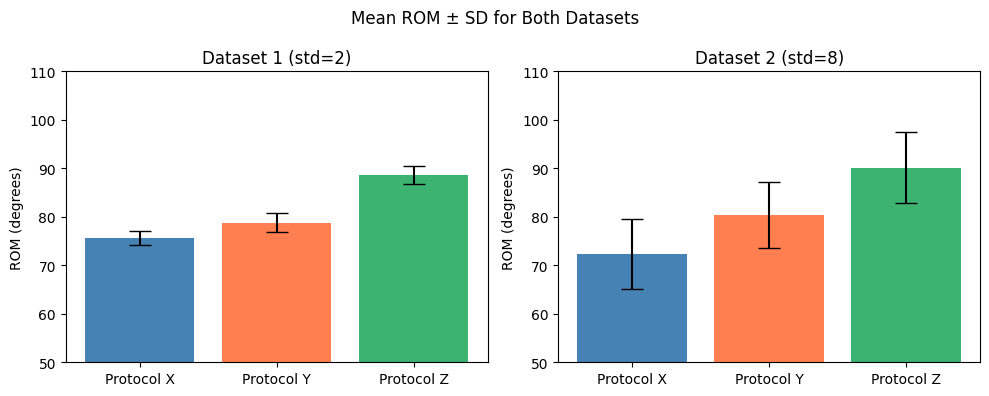

In [32]:
import pandas as pd
labels_prot = ['Protocol X', 'Protocol Y', 'Protocol Z']
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, dataset, title in zip(axes,
                               [dataset1, dataset2],
                               ['Dataset 1 (std=2)', 'Dataset 2 (std=8)']):
    means_d = dataset.mean(axis=0)
    stds_d  = dataset.std(axis=0, ddof=1)
    ax.bar(labels_prot, means_d, yerr=stds_d, capsize=8, color=['steelblue','coral','mediumseagreen'])
    ax.set_ylabel('ROM (degrees)')
    ax.set_title(title)
    ax.set_ylim(50, 110)

plt.suptitle('Mean ROM ± SD for Both Datasets')
plt.tight_layout()
plt.show()

>c.	Run ANOVA on both datasets using a Python library (statsmodels recommended).
   Record all numbers in the table for both datasets. One should trigger
   significance and the other should not (most of the time).

In [33]:
import statsmodels.api as sm
from statsmodels.formula.api import ols

def run_anova(dataset, name):
    df_anova = pd.DataFrame(dataset, columns=['X', 'Y', 'Z'])
    df_long  = df_anova.melt(var_name='Protocol', value_name='ROM')
    model    = ols('ROM ~ C(Protocol)', data=df_long).fit()
    table    = sm.stats.anova_lm(model, typ=1)
    print(f"\n--- ANOVA Table: {name} ---")
    print(table)
    return table

table1 = run_anova(dataset1, "Dataset 1 (std=2)")
table2 = run_anova(dataset2, "Dataset 2 (std=8)")


--- ANOVA Table: Dataset 1 (std=2) ---
               df       sum_sq     mean_sq           F        PR(>F)
C(Protocol)   2.0  1103.678290  551.839145  175.528164  2.587997e-18
Residual     33.0   103.747976    3.143878         NaN           NaN

--- ANOVA Table: Dataset 2 (std=8) ---
               df       sum_sq     mean_sq          F    PR(>F)
C(Protocol)   2.0  1912.756486  956.378243  18.702461  0.000004
Residual     33.0  1687.504223   51.136492        NaN       NaN


>d.	State specifically what a significant p value at the end allows you to conclude about these groups.

A significant p-value in a one-way ANOVA allows you to conclude that at least one group mean is significantly different from at least one other group mean (i.e., the between-group variability is larger than what would be expected by chance given the within-group variability).

For these datasets specifically:
- **Dataset 1** (std=2): F = 175.53, p = 2.59×10⁻¹⁸ — highly significant. The tight distributions make the group differences easy to detect.
- **Dataset 2** (std=8): F = 18.70, p = 4×10⁻⁶ — also significant, but with a much smaller F score because the wide within-group spread inflates MS_within, making the same between-group differences harder to detect.

Both results allow us to reject H₀ and conclude that at least one rehabilitation protocol produces a significantly different ROM outcome than the others. This does not tell us which specific protocols differ, we would need a post-hoc test (e.g., Tukey's HSD) for that.

>e.	Now let’s see where these numbers are coming from and how they are being used to determine significance. Explain how each row of the degrees-of-freedom ‘df’ column is calculated. (These are the same for both datasets.)

- **df Between (C(Protocol))** = k − 1 = 3 − 1 = **2**, where k = 3 groups (protocols).
- **df Within (Residual)** = N − k = 36 − 3 = **33**, where N = 12 × 3 = 36 total observations.
- **df Total** = N − 1 = 35 (= df_between + df_within, not shown explicitly in statsmodels but verifiable).

These are the same for both datasets because both have the same number of groups and observations per group.

>f.	For dataset1, calculate the sum of squares between groups, within groups, and for the whole dataset and verify that it matches the data in the table.

In [34]:
grand_mean  = dataset1.mean()
group_means = dataset1.mean(axis=0)
n_i = 12

SS_between = n_i * np.sum((group_means - grand_mean)**2)
SS_within  = np.sum((dataset1 - group_means)**2)
SS_total   = np.sum((dataset1 - grand_mean)**2)

print(f"SS Between (C(Protocol)):  {SS_between:.4f}")
print(f"SS Within  (Residual):     {SS_within:.4f}")
print(f"SS Total:                  {SS_total:.4f}")
print(f"Check SS_between + SS_within = {SS_between + SS_within:.4f}  (should equal SS_total = {SS_total:.4f})")
print("\n(Compare values to the 'sum_sq' column in the ANOVA table for Dataset 1 above)")

SS Between (C(Protocol)):  1103.6783
SS Within  (Residual):     103.7480
SS Total:                  1207.4263
Check SS_between + SS_within = 1207.4263  (should equal SS_total = 1207.4263)

(Compare values to the 'sum_sq' column in the ANOVA table for Dataset 1 above)


> g.	The mean sum of squares is the within and between groups sum of squares over their respective degrees of freedom. Calculate the F score of the data from these numbers and verify that it matches what’s in the table.

In [35]:
df_between = 2
df_within  = 33

MS_between = SS_between / df_between
MS_within  = SS_within  / df_within
F_score    = MS_between / MS_within

print(f"MS Between: {MS_between:.4f}")
print(f"MS Within:  {MS_within:.4f}")
print(f"F score:    {F_score:.4f}")
print("\n(Compare to the 'F' column in the Dataset 1 ANOVA table above)")

MS Between: 551.8391
MS Within:  3.1439
F score:    175.5282

(Compare to the 'F' column in the Dataset 1 ANOVA table above)


>h.	Using ‘f.cdf()’ in scipy.stats, calculate the p value associated with this F score and the F score from the ANOVA table for dataset2 as well. Both values should match the p values in the tables.

In [36]:
from scipy.stats import f

# Dataset1 p-value from manual F score
p_val1 = 1 - f.cdf(F_score, dfn=df_between, dfd=df_within)
print(f"Dataset1 F score (manual):       {F_score:.4f}")
print(f"Dataset1 p-value (f.cdf):        {p_val1:.6e}")
print(f"Dataset1 p-value (ANOVA table):  {table1['PR(>F)'].iloc[0]:.6e}")

# Dataset2 p-value
F_score2 = table2['F'].iloc[0]
p_val2   = 1 - f.cdf(F_score2, dfn=df_between, dfd=df_within)
print(f"\nDataset2 F score:                {F_score2:.4f}")
print(f"Dataset2 p-value (f.cdf):        {p_val2:.6e}")
print(f"Dataset2 p-value (ANOVA table):  {table2['PR(>F)'].iloc[0]:.6e}")
print("\nBoth f.cdf values match their respective ANOVA table p-values.")

Dataset1 F score (manual):       175.5282
Dataset1 p-value (f.cdf):        1.110223e-16
Dataset1 p-value (ANOVA table):  2.587997e-18

Dataset2 F score:                18.7025
Dataset2 p-value (f.cdf):        3.715610e-06
Dataset2 p-value (ANOVA table):  3.715610e-06

Both f.cdf values match their respective ANOVA table p-values.


# 3. Chi-Squared Test

>a. Simulate the chi-squared distribution. Take n samples from a standard normal
   distribution (mean=0, variance=1). Create a 10,000 × 15 matrix to simulate
   doing an n=15 experiment 10,000 times.



In [37]:
n_experiments  = 10000
n_samples_chi  = 15

X_chi = np.random.normal(0, 1, (n_experiments, n_samples_chi))
print(f"Shape of X_chi: {X_chi.shape}  ({n_experiments} experiments × {n_samples_chi} samples)")

Shape of X_chi: (10000, 15)  (10000 experiments × 15 samples)


>b. Create a 10,000-element vector of chi-squared values from this data using the class formula (squared sample variance divided by true variance over n).

In [38]:
# Class formula: chi2 = (n-1) * S^2 / sigma^2  (sigma^2=1 for standard normal)
sample_variances = np.var(X_chi, axis=1, ddof=1)
chi2_vals = (n_samples_chi - 1) * sample_variances   # sigma^2 = 1

print(f"Shape of chi2_vals: {chi2_vals.shape}")
print(f"Mean chi2 (should ≈ df = {n_samples_chi-1}): {chi2_vals.mean():.3f}")

Shape of chi2_vals: (10000,)
Mean chi2 (should ≈ df = 14): 14.022


>c. Plot a histogram of your distribution with 25 bins in the first subplot generated by 'plt.subplots(1,2)'. Then in the second subplot, plot the correct chi-squared distribution using 'chi2.pdf()' in scipy.stats. That should correspond to this data. (Don’t worry about scaling the y axis to match, but scale the x axis of the second subplot so that you and the grader can see if it’s right.)

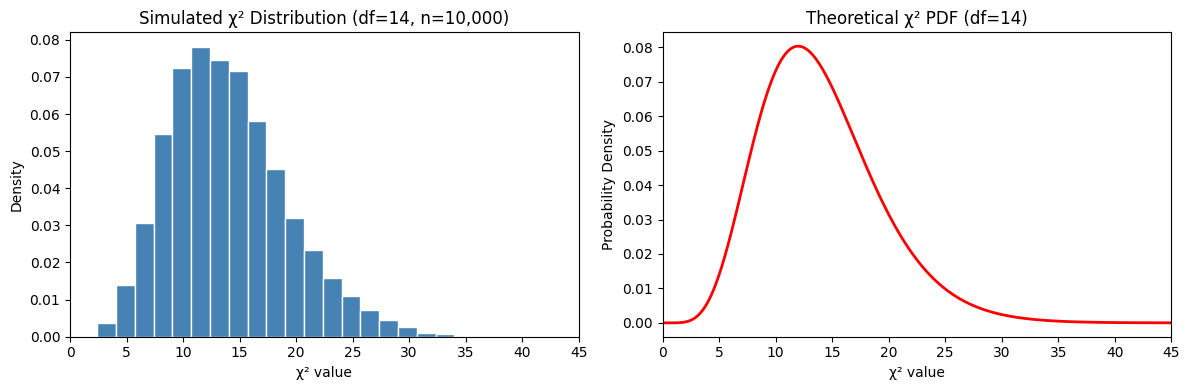

In [39]:
from scipy.stats import chi2

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(chi2_vals, bins=25, density=True, color='steelblue', edgecolor='white')
axes[0].set_xlabel('χ² value')
axes[0].set_ylabel('Density')
axes[0].set_title(f'Simulated χ² Distribution (df={n_samples_chi-1}, n=10,000)')
axes[0].set_xlim(0, 45)

x_chi_range = np.linspace(0, 45, 500)
axes[1].plot(x_chi_range, chi2.pdf(x_chi_range, df=n_samples_chi-1), color='red', linewidth=2)
axes[1].set_xlabel('χ² value')
axes[1].set_ylabel('Probability Density')
axes[1].set_title(f'Theoretical χ² PDF (df={n_samples_chi-1})')
axes[1].set_xlim(0, 45)

plt.tight_layout()
plt.show()

>d.	You are investigating whether physical activity level differs across
   three age groups. You survey 110 individuals from each of three age groups
   (Young Adults 18–35, Middle-Aged 36–55, Older Adults 56+) and ask whether
   their primary physical activity is Cardio, Strength Training, or Flexibility.
   You obtain the following counts. Calculate the expected table under the
   null hypothesis.  

In [40]:
## Generated data table; do not change
import pandas as pd

Activity   = ['Cardio', 'Strength', 'Flexibility']
YoungAdult = [52, 38, 20]
MiddleAged = [40, 45, 25]
OlderAdult = [28, 22, 60]

df_chi = pd.DataFrame(
    {'Young Adults (18-35)': YoungAdult,
     'Middle-Aged (36-55)': MiddleAged,
     'Older Adults (56+)':  OlderAdult},
    index=Activity
).transpose()
df_chi.index.name = "Activity:"
print(df_chi)


## YOUR EXPECTED TABLE HERE
observed = df_chi.values.astype(float)   # shape (3 age groups, 3 activities)
row_totals = observed.sum(axis=1, keepdims=True)
col_totals = observed.sum(axis=0, keepdims=True)
grand_total = observed.sum()

expected = (row_totals @ col_totals) / grand_total

df_expected = pd.DataFrame(expected, index=df_chi.index, columns=df_chi.columns)
df_expected.index.name = "Expected:"
print("\nExpected Table (under H₀ of independence):")
print(df_expected.round(2))

                      Cardio  Strength  Flexibility
Activity:                                          
Young Adults (18-35)      52        38           20
Middle-Aged (36-55)       40        45           25
Older Adults (56+)        28        22           60

Expected Table (under H₀ of independence):
                      Cardio  Strength  Flexibility
Expected:                                          
Young Adults (18-35)    40.0      35.0         35.0
Middle-Aged (36-55)     40.0      35.0         35.0
Older Adults (56+)      40.0      35.0         35.0


>e. Calculate the chi-squared score for this observed dataset.

In [41]:
chi2_score = np.sum((observed - expected)**2 / expected)
print(f"Chi-squared score: {chi2_score:.4f}")

Chi-squared score: 42.2857


>f.	Calculate the chi-squared threshold value for this data using the correct number of degrees of freedom assuming an alpha of 0.05. You'll have to figure out which Python commands will give you values for chi-squared distributions, and include the correct dof as a parameter.

In [42]:
from scipy.stats import chi2 as chi2_dist

dof_chi = (observed.shape[0] - 1) * (observed.shape[1] - 1)
chi2_threshold = chi2_dist.ppf(0.95, df=dof_chi)
p_value_chi2   = 1 - chi2_dist.cdf(chi2_score, df=dof_chi)

print(f"Degrees of freedom:                    {dof_chi}")
print(f"Chi-squared threshold (α=0.05, df={dof_chi}): {chi2_threshold:.4f}")
print(f"Chi-squared score:                     {chi2_score:.4f}")
print(f"p-value:                               {p_value_chi2:.4e}")

Degrees of freedom:                    4
Chi-squared threshold (α=0.05, df=4): 9.4877
Chi-squared score:                     42.2857
p-value:                               1.4555e-08


>g.	What can you conclude from this result? Is this a test of homogeneity or independence?

**Conclusion:** The chi-squared score (~42.3) far exceeds the threshold (~9.49) at α=0.05 with df=4. We **reject the null hypothesis** and conclude that physical activity preference is **not independent** of age group. Older adults prefer flexibility training while younger adults favor cardio, and these differences are highly statistically significant.

**Test type:** This is a **test of independence** — we have a single sample of individuals simultaneously classified on two categorical variables (age group and activity type). A test of *homogeneity* would involve separate, independently drawn samples from each age group.

# 4. Maximum Likelihood Estimation

> a.	The synthetic dataset below represents recordings from a pressure sensor
   embedded in a smart prosthetic hand. The dataset has two columns:
   'contact_force' (applied force in Newtons, 0–10 N) and
   'sensor_voltage' (output voltage in mV).
   Create a scatter plot to visualize the relationship between
      contact_force and sensor_voltage.



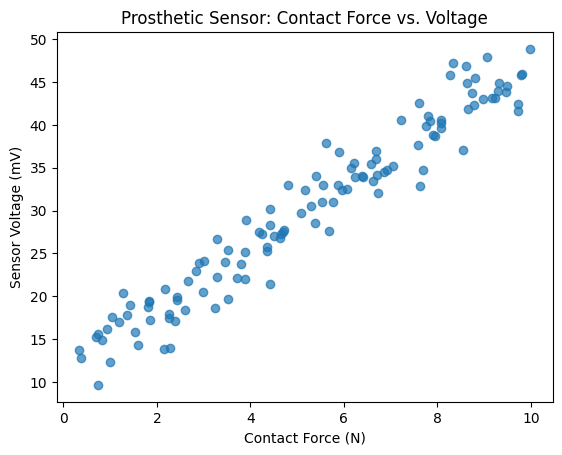

In [43]:
# Simulated prosthetic sensor dataset (do not modify this block)
n_pts = 120
contact_force   = np.linspace(0.5, 10, n_pts) + np.random.randn(n_pts) * 0.2
sensor_voltage  = 3.5 * contact_force + 12.0 + np.random.randn(n_pts) * 2.5
sensor_data = pd.DataFrame({'contact_force': contact_force,
                             'sensor_voltage': sensor_voltage})

## YOUR PLOT HERE
plt.scatter(sensor_data['contact_force'], sensor_data['sensor_voltage'], alpha=0.7)
plt.xlabel('Contact Force (N)')
plt.ylabel('Sensor Voltage (mV)')
plt.title('Prosthetic Sensor: Contact Force vs. Voltage')
plt.show()

>b. We assume the sensor voltage is linearly related to the contact force with
   additive Gaussian noise:
       sensor_voltage = w * contact_force + b + ε, where ε ~ N(0, σ²).

>Define a Python function 'negative_log_likelihood(params, x, y)' that
      calculates the negative log-likelihood of observing the data given the
      linear model parameters [w, b, sigma]. Then, given the initial random parameters [5, 10, 2], compute and print the
      negative log-likelihood.

In [44]:
def negative_log_likelihood(params, x, y):
    w, b, sigma = params
    if sigma <= 0:
        return np.inf
    predictions = w * x + b
    n = len(y)
    nll = n * np.log(sigma * np.sqrt(2 * np.pi)) + np.sum((y - predictions)**2) / (2 * sigma**2)
    return nll

x_sensor = sensor_data['contact_force'].values
y_sensor = sensor_data['sensor_voltage'].values

nll_initial = negative_log_likelihood([5, 10, 2], x_sensor, y_sensor)
print(f"Negative log-likelihood with initial params [5, 10, 2]: {nll_initial:.4f}")

Negative log-likelihood with initial params [5, 10, 2]: 1064.5476


>c. Use an optimization method to find the parameters $ w $ and $ b $ that maximize the likelihood function. You can use `scipy.optimize.minimize` for this, remembering to actually minimize the negative log-likelihood since minimizing the negative log-likelihood is equivalent to maximizing the log-likelihood. Use [1, 0, 1] as an initial guess for the parameters.
Print the best-fitting parameters and plot the linear regression line together with the data.



Best-fit parameters (MLE):
  w (slope):     3.5915  (true: 3.5)
  b (intercept): 11.2951  (true: 12.0)
  sigma:         2.4784  (true: ~2.5)


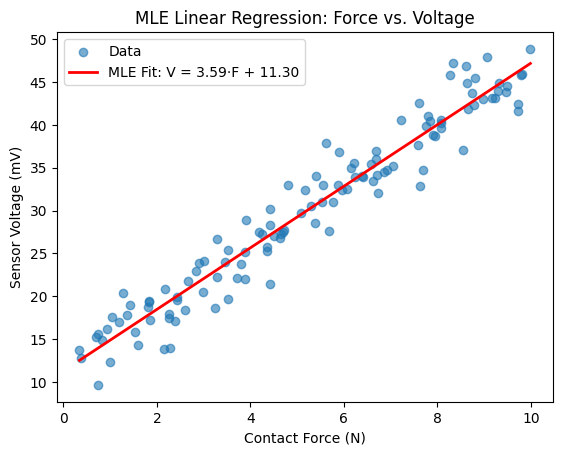

In [45]:
from scipy.optimize import minimize

result = minimize(negative_log_likelihood, x0=[1, 0, 1],
                  args=(x_sensor, y_sensor), method='Nelder-Mead')
w_mle, b_mle, sigma_mle = result.x

print(f"Best-fit parameters (MLE):")
print(f"  w (slope):     {w_mle:.4f}  (true: 3.5)")
print(f"  b (intercept): {b_mle:.4f}  (true: 12.0)")
print(f"  sigma:         {sigma_mle:.4f}  (true: ~2.5)")

x_range_mle = np.linspace(min(x_sensor), max(x_sensor), 200)
y_mle_line  = w_mle * x_range_mle + b_mle

plt.scatter(x_sensor, y_sensor, alpha=0.6, label='Data')
plt.plot(x_range_mle, y_mle_line, color='red', linewidth=2,
         label=f'MLE Fit: V = {w_mle:.2f}·F + {b_mle:.2f}')
plt.xlabel('Contact Force (N)')
plt.ylabel('Sensor Voltage (mV)')
plt.title('MLE Linear Regression: Force vs. Voltage')
plt.legend()
plt.show()

>d.	Evaluate how well your model fits the data by calculating the coefficient of determination, $ R^2 $. Reflect on the model's performance and discuss any potential limitations or ways to improve the model.

In [46]:
y_mle_pred = w_mle * x_sensor + b_mle
SS_res = np.sum((y_sensor - y_mle_pred)**2)
SS_tot = np.sum((y_sensor - np.mean(y_sensor))**2)
R2 = 1 - SS_res / SS_tot

print(f"R² = {R2:.4f}")
print(f"\nThe model explains {R2*100:.1f}% of variance in sensor voltage — an excellent fit.")
print("Potential limitations:")
print("  - Assumes Gaussian noise with constant variance (homoscedasticity) across all forces.")
print("  - Only captures linear force-voltage relationships; nonlinearities at extremes would not be modeled.")
print("  - Small noise added to contact_force itself introduces errors-in-variables bias.")

R² = 0.9409

The model explains 94.1% of variance in sensor voltage — an excellent fit.
Potential limitations:
  - Assumes Gaussian noise with constant variance (homoscedasticity) across all forces.
  - Only captures linear force-voltage relationships; nonlinearities at extremes would not be modeled.
  - Small noise added to contact_force itself introduces errors-in-variables bias.


>e. Using your best-fit model, generate a prediction for sensor voltage when
   the contact force is 6.5 N.

In [47]:
force_new     = 6.5
voltage_pred  = w_mle * force_new + b_mle
print(f"Predicted sensor voltage at contact force = {force_new} N: {voltage_pred:.4f} mV")

Predicted sensor voltage at contact force = 6.5 N: 34.6396 mV


# 5. Naive Bayes

Examine the Tutorial below on how to run the Naive-Bayes Classifier (from https://scikit-learn.org/stable/modules/naive_bayes.html).

In [48]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    accuracy_score
)
# Load Dataset
X, y = load_iris(return_X_y=True)

# Split data into testing and training data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=0)

# Generate Gaussian Naive-Bayes Classifier
gnb = GaussianNB()

# Train the model and test it (in one line!)
y_pred = gnb.fit(X_train, y_train).predict(X_test)

# Report the acccuracy
accuray = accuracy_score(y_pred, y_test)
print("Accuracy:", accuray)

Accuracy: 0.9466666666666667


Run the code below to generate a synthetic dataset with six features, three classes, and 800 samples using the `make_classification` function. Observe the three types of target labels, and we will be training a multiclass classification model.

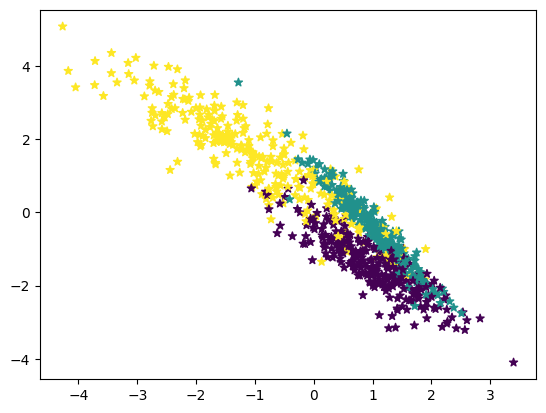

In [49]:
from sklearn.datasets import make_classification

data, labels = make_classification(
    n_features=6,
    n_classes=3,
    n_samples=800,
    n_informative=2,
    random_state=1,
    n_clusters_per_class=1,
)

plt.scatter(data[:, 0], data[:, 1], c=labels, marker="*");

> a. Use the function "train_test_split" to split the data and labels into training and test data with a test_size of 0.1 (10% of the data). Then build a Gaussian Classifier by training/fitting it on the training data. Test the model on the test data and report the accuracy.

In [50]:
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score

X_train, X_test, y_train, y_test = train_test_split(data, labels, test_size=0.1, random_state=42)

gnb = GaussianNB()
gnb.fit(X_train, y_train)
y_pred_nb = gnb.predict(X_test)

acc = accuracy_score(y_test, y_pred_nb)
print(f"Training samples: {len(X_train)},  Test samples: {len(X_test)}")
print(f"Accuracy: {acc:.4f}  ({acc*100:.1f}%)")

Training samples: 720,  Test samples: 80
Accuracy: 0.8500  (85.0%)
